In [1]:
import pandas as pd 
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import os
import re
import importlib

This is the data from the email! Had a lot of bad luck with trying to get it myself... (see doc, when written).
Nothng is particularly novel yet. And sorry, no pipeline... (but a few steps are very general).

In [2]:
data_path = os.path.abspath("../data/tcga_data2.csv")

raw_df = pd.read_csv(data_path, sep = '\t', low_memory = False)
raw_df.head(1)

,Gene,Study of Origin,Sample ID,Cancer Type,Cancer Type Detailed,Protein Change,Annotation,Custom Driver,Custom Driver Tiers,Functional Impact,...,Tumor Type,Used in Genomic Analysis,Vascular invasion indicator,Vessel Invasion,Vial number,Patient's Vital Status,Patient Weight,WGD,Winter Hypoxia Score,Year of Diagnosis
0,APC,"Colorectal Adenocarcinoma (TCGA, Firehose Legacy)",TCGA-AA-A010-01,Colorectal Cancer,Colon Adenocarcinoma,A2D,"OncoKB: Unknown, level NA, resistance NA;reVUE...",NaN,NaN,MutationAssessor: NA;SIFT: impact: deleterious...,...,NaN,NaN,NO,NaN,A,NaN,NaN,NaN,NaN,NaN


In [3]:
# https://docs.python.org/3/library/re.html
# \b is a space
cols = np.array(raw_df.columns.tolist())
pattern = re.compile(r'\bage\b', flags = re.IGNORECASE)
age_cols = np.array([])

for col in cols:
    # Regex needs pattern.search, instead of say "str".in(array)
    if pattern.search(col) and ("Diagnosis" in col):
        age_cols = np.append(age_cols, col)

age_cols

array(['Diagnosis Age', 'Age at Diagnosis', 'Age At Diagnosis'],
      dtype='<U32')

In [4]:
note_cols = ["Gene", "Sample ID", "Cancer Type Detailed", "Mutation Type", "Variant Type", "HGVSc", "MS", 
        "Protein Change", "Functional Impact"]

good_cols = np.concatenate((note_cols, age_cols))
df = raw_df[good_cols].copy()

# Gene expression as in email
# df = short_df[short_df["HGVSc"] == "ENST00000257430.4:c.835-8A>G"]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6501 entries, 0 to 6500
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Gene                  6501 non-null   object 
 1   Sample ID             6501 non-null   object 
 2   Cancer Type Detailed  6501 non-null   object 
 3   Mutation Type         6501 non-null   object 
 4   Variant Type          6498 non-null   object 
 5   HGVSc                 5660 non-null   object 
 6   MS                    3188 non-null   object 
 7   Protein Change        6501 non-null   object 
 8   Functional Impact     6501 non-null   object 
 9   Diagnosis Age         3096 non-null   float64
 10  Age at Diagnosis      1477 non-null   float64
 11  Age At Diagnosis      304 non-null    float64
dtypes: float64(3), object(9)
memory usage: 609.6+ KB


In [5]:
# Stolen bfill from you! Axis = 1 looks across columns
df.loc[:, 'Age'] = df[age_cols].bfill(axis = 1).iloc[:, 0]
df = df.drop(columns = age_cols)

In [6]:
early_age = 50
df["Early Onset"] = df["Age"] < early_age
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6501 entries, 0 to 6500
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Gene                  6501 non-null   object 
 1   Sample ID             6501 non-null   object 
 2   Cancer Type Detailed  6501 non-null   object 
 3   Mutation Type         6501 non-null   object 
 4   Variant Type          6498 non-null   object 
 5   HGVSc                 5660 non-null   object 
 6   MS                    3188 non-null   object 
 7   Protein Change        6501 non-null   object 
 8   Functional Impact     6501 non-null   object 
 9   Age                   4877 non-null   float64
 10  Early Onset           6501 non-null   bool   
dtypes: bool(1), float64(1), object(9)
memory usage: 514.4+ KB


In [7]:
df = df.dropna(subset = ["Age"], axis = 0)
df = df.drop_duplicates(subset = ["Sample ID", "HGVSc"], keep = "first")
# NOTE Changed this from just subset = ["Sample ID"] to ["Sample ID", "HGVSc"]
# =====================================

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4464 entries, 0 to 6500
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Gene                  4464 non-null   object 
 1   Sample ID             4464 non-null   object 
 2   Cancer Type Detailed  4464 non-null   object 
 3   Mutation Type         4464 non-null   object 
 4   Variant Type          4461 non-null   object 
 5   HGVSc                 4025 non-null   object 
 6   MS                    1308 non-null   object 
 7   Protein Change        4464 non-null   object 
 8   Functional Impact     4464 non-null   object 
 9   Age                   4464 non-null   float64
 10  Early Onset           4464 non-null   bool   
dtypes: bool(1), float64(1), object(9)
memory usage: 388.0+ KB


In [9]:
df[df["HGVSc"] == "ENST00000257430.4:c.835-8A>G"].shape

(35, 11)

---

---

Next steps could include:
1. Start some Bayesian stats to test whether c.835-8A>G carriers are younger at diagnosis than patients with other APC mutations, (some simple models would be easy enough to run in R),
1. Look at the mutation type `value_counts()` and see if the mutation type differs across age groups,
1. Visualise both of these ideas.

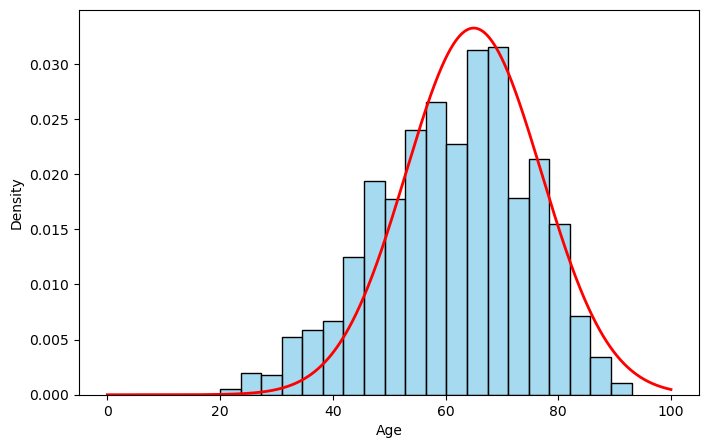

In [10]:
# ==============
# Looking at the distribution of ages.
# RESULTS: mu=65, sigma=12 seems reasonable for the data likelihood... 
# Really this should be validated.
# ALSO: the distribution is (obviously, people don't live past ~90 as often) quite left skewed
from scipy.stats import norm

fig, ax = plt.subplots(figsize = (8, 5))
# density scales it (so it matches scale of normal dist)
sns.histplot(df['Age'], stat = "density", color = 'skyblue', bins = 20)

x_prior = np.linspace(0, 100, 1000)
y_prior = norm.pdf(x_prior, loc = 65, scale = 12)
ax.plot(x_prior, y_prior, color = 'red', lw = 2)

# mu = 65
# +- 2sgima = 40, 90 (95% rule)
# sigma = 12

plt.show()

In [11]:
df["HGVSc Interest"] = (df["HGVSc"] == "ENST00000257430.4:c.835-8A>G").astype(int)
df["HGVSc Interest"].value_counts()

HGVSc Interest
0    4429
1      35
Name: count, dtype: int64

In [12]:
small_df = df[["HGVSc Interest", "Age"]]
small_df.to_csv("small_df.csv", index = False)

---
---
---

Testing the `clean_data()` function in `cleaning.py` works as intended.

In [13]:
# Import the .py module.
import cleaning as clean
importlib.reload(clean)

data_path = os.path.abspath("../data/tcga_data2.csv")
raw_df = pd.read_csv(data_path, sep = '\t', low_memory = False)
raw_df.head(1)

,Gene,Study of Origin,Sample ID,Cancer Type,Cancer Type Detailed,Protein Change,Annotation,Custom Driver,Custom Driver Tiers,Functional Impact,...,Tumor Type,Used in Genomic Analysis,Vascular invasion indicator,Vessel Invasion,Vial number,Patient's Vital Status,Patient Weight,WGD,Winter Hypoxia Score,Year of Diagnosis
0,APC,"Colorectal Adenocarcinoma (TCGA, Firehose Legacy)",TCGA-AA-A010-01,Colorectal Cancer,Colon Adenocarcinoma,A2D,"OncoKB: Unknown, level NA, resistance NA;reVUE...",NaN,NaN,MutationAssessor: NA;SIFT: impact: deleterious...,...,NaN,NaN,NO,NaN,A,NaN,NaN,NaN,NaN,NaN


In [14]:
relevant = ["Gene", "Sample ID", "Cancer Type Detailed", "Mutation Type", "Variant Type", "HGVSc", "MS", 
        "Protein Change", "Functional Impact"]

clean_df = clean.clean_data(raw_df,
                relevant_cols = relevant, early_age = 50)

clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4464 entries, 0 to 6500
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Gene                  4464 non-null   object 
 1   Sample ID             4464 non-null   object 
 2   Cancer Type Detailed  4464 non-null   object 
 3   Mutation Type         4464 non-null   object 
 4   Variant Type          4461 non-null   object 
 5   HGVSc                 4025 non-null   object 
 6   MS                    1308 non-null   object 
 7   Protein Change        4464 non-null   object 
 8   Functional Impact     4464 non-null   object 
 9   Age                   4464 non-null   float64
 10  Early Onset           4464 non-null   bool   
dtypes: bool(1), float64(1), object(9)
memory usage: 388.0+ KB


In [15]:
# Compare to the original.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4464 entries, 0 to 6500
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Gene                  4464 non-null   object 
 1   Sample ID             4464 non-null   object 
 2   Cancer Type Detailed  4464 non-null   object 
 3   Mutation Type         4464 non-null   object 
 4   Variant Type          4461 non-null   object 
 5   HGVSc                 4025 non-null   object 
 6   MS                    1308 non-null   object 
 7   Protein Change        4464 non-null   object 
 8   Functional Impact     4464 non-null   object 
 9   Age                   4464 non-null   float64
 10  Early Onset           4464 non-null   bool   
 11  HGVSc Interest        4464 non-null   int64  
dtypes: bool(1), float64(1), int64(1), object(9)
memory usage: 422.9+ KB


Lovely stuff.

---
---
---


Coding the Mann-Whitney $U$ test (and then comparing to the SciPy results).

In [16]:
def mwu(sample1, sample2, report = True):
    ''' 
    Performs the Mann-Whitney U test on two independent samples (1D).
    E.g. compare the Age distribution of two cancer cohorts.

    NOTE This is not particuarly efficient, but N is normally small.
    NOTE Issues if there is tied data (minor issues)
    NOTE Can just use the SciPY MWU test...
    '''

    # If not already NumPy arrays.
    sample1 = np.array(sample1)
    sample2 = np.array(sample2)

    # Creates DF with labelled entries.
    # NOTE More efficient code would refactor this (and the iterrows().)
    df1 = pd.DataFrame({"Data": sample1, "Dist": 1})
    df2 = pd.DataFrame({"Data": sample2, "Dist": 2})
    df = pd.concat([df1, df2])

    # Sort by data.
    df = df.sort_values(by = "Data").reset_index()

    # Initiate rank-sum arrays and loop.
    rank_sum1 = np.zeros_like(sample1)
    rank_sum2 = np.zeros_like(sample2)
    i = 0; j = 0; # i for rs1, j for rs2.

    # NOTE Better code would avoid looping.
    for index, row in df.iterrows():
        # index + 1 because Pandas is 0-indexed.
        if row["Dist"] == 1:
            rank_sum1[i] = index + 1
            i += 1
        else:
            rank_sum2[j] = index + 1
            j += 1

    # Calculate the U-values.
    n1 = sample1.shape[0]; n2 = sample2.shape[0]
    R1 = rank_sum1.sum(); R2 = rank_sum2.sum()

    U1 = (n1*n2) + (n1*(n1+1))/2 - R1
    U2 = (n1*n2) + (n2*(n2+1))/2 - R2
    U = min(U1, U2)

    # Expected value, standard deviation, use to find Z-value.
    U_exp = (n1*n2)/2
    U_se = np.sqrt((n1*n2*(n1 + n2 + 1))/12)
    z = (U - U_exp)/U_se
    # Assuming a normal dist.
    p = 2 * stats.norm.sf(abs(z))

    # The non-parametric?
    rho = U / (n1 * n2)

    if (report):
        print(f'U1, U2 are {U1}, {U2}. Non-parametric rho is {rho}.\n'
              f'Assuming a normal distribution gives z = {z}, i.e. p = {p}.')

        similar = "*evidence*" if p < 0.05 else "*no evidence*"
        print(f'\nThere is {similar} to suggest these distributions are distinct. (alpha = 0.05)')
    
    return U1, U2, rho, z, p

In [17]:
sample1 = [np.random.randint(0, 5) for j in range(10)]
sample2 =  [np.random.randint(0, 10) for j in range(10)]
print(np.sort(sample1))
print(np.sort(sample2))

U1, U2, rho, z, p = mwu(sample1, sample2)

[0 1 1 1 1 1 3 3 4 4]
[1 2 2 4 4 6 8 8 9 9]
U1, U2 are 86.0, 14.0. Non-parametric rho is 0.14.
Assuming a normal distribution gives z = -2.721344205666436, i.e. p = 0.006501702373081825.

There is *evidence* to suggest these distributions are distinct. (alpha = 0.05)


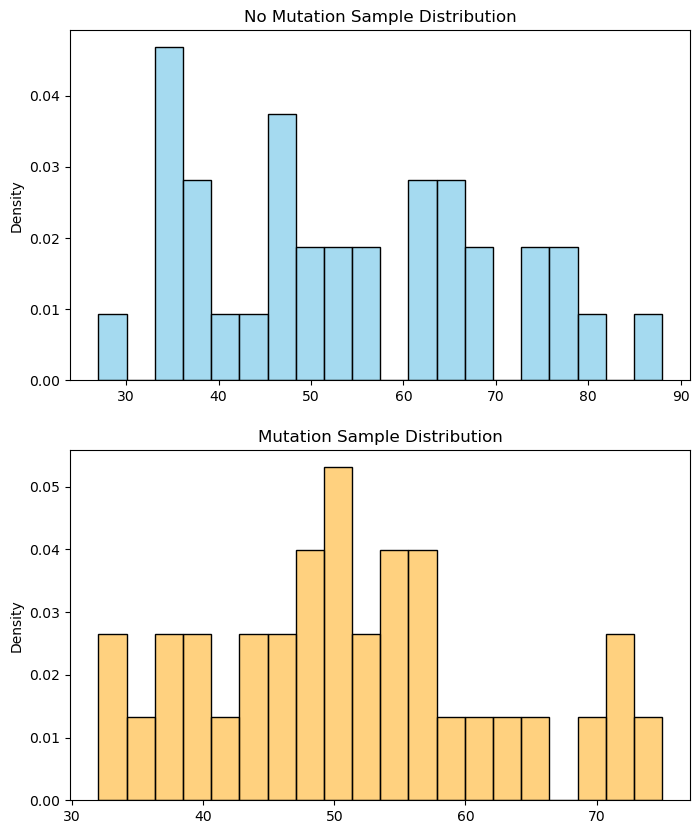

In [18]:
# ===========================
# NOTE from Abbi's .

pipeline = clean_df

# Generate a cohort of CRC samples that do not contain the mutation
no_mutation = pipeline[pipeline["HGVSc"] != "ENST00000257430.4:c.835-8A>G"]
no_mutation_sample = no_mutation.sample(n=35)
no_mutation_sample = no_mutation_sample["Age"].tolist()

# Generate the cohort of samples that do contain the mutation
mutation = pipeline[pipeline["HGVSc"] == "ENST00000257430.4:c.835-8A>G"]
mutation_sample = mutation["Age"].tolist()

fig, ax = plt.subplots(2, 1, figsize = (8, 10))

sns.histplot(no_mutation_sample, stat = "density", color = 'skyblue', bins = 20, ax = ax[0])
ax[0].set_title("No Mutation Sample Distribution")
sns.histplot(mutation_sample, stat = "density", color = 'orange', bins = 20, alpha =0.5, ax = ax[1])
ax[1].set_title("Mutation Sample Distribution")

plt.show()

In [19]:
mwu(no_mutation_sample, mutation_sample)

U1, U2 are 569.0, 656.0. Non-parametric rho is 0.46448979591836737.
Assuming a normal distribution gives z = -0.5109550093285308, i.e. p = 0.6093825607821389.

There is *no evidence* to suggest these distributions are distinct. (alpha = 0.05)


(np.float64(569.0),
 np.float64(656.0),
 np.float64(0.46448979591836737),
 np.float64(-0.5109550093285308),
 np.float64(0.6093825607821389))

In [20]:
stats.mannwhitneyu(no_mutation_sample, mutation_sample)

MannwhitneyuResult(statistic=np.float64(658.5), pvalue=np.float64(0.5928800934157707))